In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [13]:
# Load and preprocess the dataset
column = "Standing Height (cm)"
N = 1000
df = pd.read_csv("height_weight_bmi.csv", index_col=0).iloc[:N]  # Load first N rows

df.head()

,Weight (kg),Standing Height (cm),BMI(kg/m**2)
0,97.1,160.2,37.8
1,98.8,182.3,29.7
2,74.3,184.2,21.9
3,103.7,185.3,30.2
4,83.3,177.1,26.6


In [22]:

df[column] = pd.to_numeric(df[column], errors='coerce')

population_data = df[column]
population_data

0      160.2
1      182.3
2      184.2
3      185.3
4      177.1
       ...  
995    149.1
996    173.6
997    165.1
998    172.3
999    173.6
Name: Standing Height (cm), Length: 1000, dtype: float64

In [17]:
# Main workflow
population_mean = 170  # Assumed population mean
sample_size = 10


In [19]:
def random_sample(data, sample_size):
    return np.random.choice(data, size=sample_size, replace=False)

In [23]:
sample = random_sample(population_data, sample_size)
sample

array([165.1, 176.9, 151.4, 165.6, 153.8, 173.7, 171.6, 169.1, 178. ,
       171. ])

In [ ]:
t_test(sample, population_mean, alpha=0.05, tail=2)

In [24]:
alpha=0.05
tail=2

In [26]:
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
n = len(sample)
t_statistic = (sample_mean - population_mean) / (sample_std / np.sqrt(n))
dof = n - 1

# Determine critical t value based on tail type
if tail == 1:  # Left-tailed
    critical_value = stats.t.ppf(alpha, dof)
elif tail == 2:  # Two-tailed
    critical_value = stats.t.ppf(1 - alpha / 2, dof)
else:  # Right-tailed
    critical_value = stats.t.ppf(1 - alpha, dof)

critical_value, t_statistic

(2.2621571627409915, -0.8386684737466639)

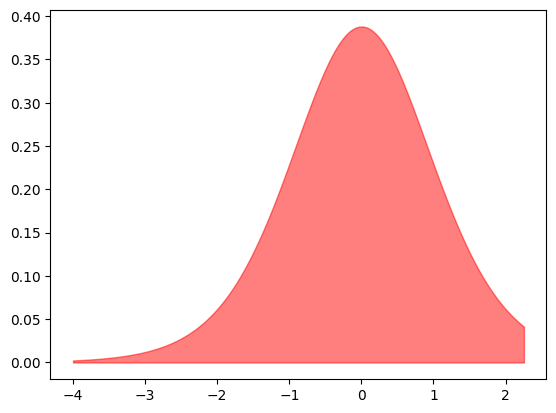

In [31]:
plt.fill_between(x, y, where=(x < critical_value), color='red', alpha=0.5, label='Critical Region')

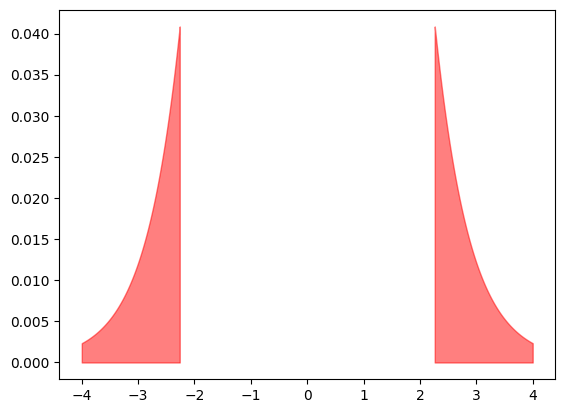

In [32]:
critical_left = stats.t.ppf(alpha / 2, dof)
critical_right = stats.t.ppf(1 - alpha / 2, dof)
plt.fill_between(x, y, where=(x < critical_left), color='red', alpha=0.5, label='Critical Region (Left)')
plt.fill_between(x, y, where=(x > critical_right), color='red', alpha=0.5, label='Critical Region (Right)')

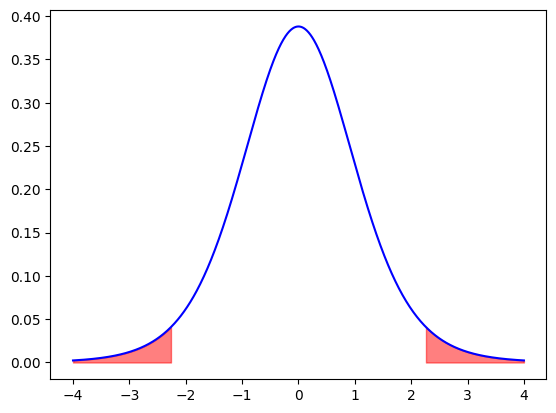

In [28]:
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=dof)
plt.plot(x, y, label='t-distribution', color='blue')

if tail == 1:  # Left-tailed
    
elif tail == 2:  # Two-tailed
    critical_left = stats.t.ppf(alpha / 2, dof)
    critical_right = stats.t.ppf(1 - alpha / 2, dof)
    plt.fill_between(x, y, where=(x < critical_left), color='red', alpha=0.5, label='Critical Region (Left)')
    plt.fill_between(x, y, where=(x > critical_right), color='red', alpha=0.5, label='Critical Region (Right)')
else:  # Right-tailed
    plt.fill_between(x, y, where=(x > critical_value), color='red', alpha=0.5, label='Critical Region')

plt.axvline(t_statistic, color='orange', linestyle='--', label='T-Statistic')
plt.title('T-Test: Critical Region and T-Statistic')
plt.xlabel('T Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid()
plt.show()

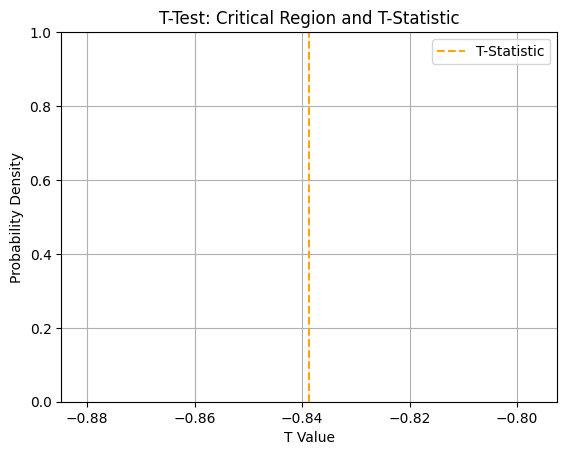

In [29]:
plt.axvline(t_statistic, color='orange', linestyle='--', label='T-Statistic')
plt.title('T-Test: Critical Region and T-Statistic')
plt.xlabel('T Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid()
plt.show()

In [ ]:








# Function to perform a t-test
def t_test(sample, population_mean, alpha=0.05, tail=2):
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    n = len(sample)
    t_statistic = (sample_mean - population_mean) / (sample_std / np.sqrt(n))
    dof = n - 1

    # Determine critical t value based on tail type
    if tail == 1:  # Left-tailed
        critical_value = stats.t.ppf(alpha, dof)
    elif tail == 2:  # Two-tailed
        critical_value = stats.t.ppf(1 - alpha / 2, dof)
    else:  # Right-tailed
        critical_value = stats.t.ppf(1 - alpha, dof)

    # Plotting the t-distribution and critical regions
    plot_t_distribution(t_statistic, critical_value, dof, alpha, tail)

    print(f"T-Statistic: {t_statistic:.4f}, Sample Mean: {sample_mean:.4f}")
    print(f"Critical Value: {critical_value:.4f}")

    # Hypothesis decision
    if (tail == 1 and t_statistic < critical_value) or \
       (tail == 2 and (t_statistic < -critical_value or t_statistic > critical_value)) or \
       (tail == 3 and t_statistic > critical_value):
        print("Reject the null hypothesis.")
    else:
        print("Fail to reject the null hypothesis.")

# Function to plot t-distribution and critical regions
def plot_t_distribution(t_statistic, critical_value, dof, alpha, tail):
    x = np.linspace(-4, 4, 1000)
    y = stats.t.pdf(x, df=dof)
    plt.plot(x, y, label='t-distribution', color='blue')
    
    if tail == 1:  # Left-tailed
        plt.fill_between(x, y, where=(x < critical_value), color='red', alpha=0.5, label='Critical Region')
    elif tail == 2:  # Two-tailed
        critical_left = stats.t.ppf(alpha / 2, dof)
        critical_right = stats.t.ppf(1 - alpha / 2, dof)
        plt.fill_between(x, y, where=(x < critical_left), color='red', alpha=0.5, label='Critical Region (Left)')
        plt.fill_between(x, y, where=(x > critical_right), color='red', alpha=0.5, label='Critical Region (Right)')
    else:  # Right-tailed
        plt.fill_between(x, y, where=(x > critical_value), color='red', alpha=0.5, label='Critical Region')
    
    plt.axvline(t_statistic, color='orange', linestyle='--', label='T-Statistic')
    plt.title('T-Test: Critical Region and T-Statistic')
    plt.xlabel('T Value')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid()
    plt.show()